# ML Hack day

A typical machine learning (ML) training pipeline looks like this:

1. Define the problem and specify the output metrics for evaluating the solution.
2. Obtain a dataset that captures the features relevant to the problem.
        2.1 Split the data into training, validation and testing sets.
3. Preprocess the data in the dataset, if necessary.
4. Define the hyperparameters for training the model.
5. Design the model to be trained:
        5.1 Create the model from scratch.
        5.2 Alternatively, use a pretrained model.
6. Train the model and run inference on the testing data.
        6.1 If the output metrics are not satisfactory, return to step 4 and make necessary adjustments (e.g., tweak hyperparameters or modify the model architecture).
7. Deploy the model into production (in the wild).

In [3]:
a = (1,2)
b = (3,4)
a = a + b

In [4]:
print(a)

(1, 2, 3, 4)


In [1]:
bool("" and True)

False

In [7]:
import numpy as np 
from scipy import stats 
 
# Define the integer sequence 
data = [3, 2, 2, 2, 6] 
 
# Calculate median, variance, and mode 
median = np.median(data) 
variance = np.var(data, ddof=0)  # Population variance 
mode = stats.mode(data)[0]
 
median, variance, mode

(2.0, 2.4, 2)

In [9]:
def f(values):
    values[0] = 42
values = [1, 2, 3]
f(values)
print(values)

[42, 2, 3]


In [8]:
np.dot(
    np.array([[1,2],[2,3]]),
    np.array([[0,1],[1,1]])
)


array([[2, 3],
       [3, 5]])

## 1. Define the problem.
### Classify astronomical objects using machine learning and computer vision algorithms. The output metric is classification accuracy.

## Installing necessary libraries

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import layers, models
import time

## 2. Obtain a representative dataset
### The current data is just a list of images. This list needs to be divided into training, validation and testing folders

In [3]:
import os
import shutil
import random

# Kaggle specific paths
dataset_dir = '/kaggle/input/spacenet-an-optimally-distributed-astronomy-data/SpaceNet.FLARE.imam_alam'  # Path to your dataset in Kaggle
output_dir = '/kaggle/working/dataset'  # Output folder where the split dataset will be stored

# Specify the classes you want to process
selected_classes = ['asteroid', 'black hole', 'comet', 'nebula', 'constellation']

def create_split_folders(base_dir, classes):
    for split in ['train', 'valid', 'test']:
        for class_name in classes:
            split_path = os.path.join(base_dir, split, class_name)
            os.makedirs(split_path, exist_ok=True)

def split_dataset(dataset_dir, output_dir, selected_classes, train_ratio=0.7, valid_ratio=0.2, test_ratio=0.1):
#     if train_ratio + valid_ratio + test_ratio != 1.0:
#         raise ValueError("The sum of train_ratio, valid_ratio, and test_ratio must be 1.0")
    
    create_split_folders(output_dir, selected_classes)
    
    for class_name in selected_classes:
        class_path = os.path.join(dataset_dir, class_name)
        if not os.path.exists(class_path):
            print(f"Class '{class_name}' not found in the dataset. Skipping.")
            continue
        
        images = os.listdir(class_path)
        random.shuffle(images)
        
        train_split = int(train_ratio * len(images))
        valid_split = int(valid_ratio * len(images)) + train_split
        
        train_images = images[:train_split]
        valid_images = images[train_split:valid_split]
        test_images = images[valid_split:]
        
        for image in train_images:
            src_path = os.path.join(class_path, image)
            dest_path = os.path.join(output_dir, 'train', class_name, image)
            shutil.copyfile(src_path, dest_path)
        
        for image in valid_images:
            src_path = os.path.join(class_path, image)
            dest_path = os.path.join(output_dir, 'valid', class_name, image)
            shutil.copyfile(src_path, dest_path)
        
        for image in test_images:
            src_path = os.path.join(class_path, image)
            dest_path = os.path.join(output_dir, 'test', class_name, image)
            shutil.copyfile(src_path, dest_path)
    
    print(f"Dataset split into train, valid, and test sets in {output_dir}")

# Run the function
split_dataset(dataset_dir, output_dir, selected_classes, train_ratio=0.7, valid_ratio=0.2, test_ratio=0.1)


Dataset split into train, valid, and test sets in /kaggle/working/dataset


In [4]:
# Define dataset paths
dataset_dir = "/kaggle/working/dataset"
train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "valid")
test_dir = os.path.join(dataset_dir, "test")

## 3. Preprocess the dataset by rescaling, rotating, shifting, etc...

In [11]:
# ImageDataGenerator for data augmentation and loading
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

## 4. Define values for hyperparameters

In [12]:
# Hyperparameters and Parameters
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
EPOCHS = 3
REGULARIZATION_RATE = 0.01
LEARNING_RATE = 0.001
CLASS_MODE = 'categorical'

In [13]:
# Data generators used for extracting formated input images for the model.
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE
)

Found 2868 images belonging to 5 classes.


In [14]:
val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE
)

Found 818 images belonging to 5 classes.


In [15]:
test_generator = val_test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=CLASS_MODE,
    shuffle=False
)

Found 413 images belonging to 5 classes.


## 5. Define the learning model

### 5.1. Creating a custom model from scratch

In [16]:
# 2. Define the CNN architecture
model = models.Sequential()

# First convolutional layer: 32 filters, 3x3 kernel, ReLU activation, followed by MaxPooling
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second convolutional layer: 64 filters, 3x3 kernel, ReLU activation, followed by MaxPooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Third convolutional layer: 64 filters, 3x3 kernel, ReLU activation
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten the 3D output to 1D to pass to a Dense layer
model.add(layers.Flatten())

# Fully connected layer: 64 units, ReLU activation
model.add(layers.Dense(64, activation='relu'))

# Output layer: 5 units (for 5 classes), softmax activation
model.add(layers.Dense(5, activation='softmax'))

### 5.2. Creating a model from an already pretrained one. (More efficient this way)

In [33]:
# Build the model using EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(len(selected_classes), activation='softmax', kernel_regularizer=l2(REGULARIZATION_RATE))(x)
model = Model(inputs=base_model.input, outputs=predictions)

Exception: URL fetch failure on https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5: None -- [Errno -3] Temporary failure in name resolution

### Configure the Learning Process
Compiling the model defines the optimization process that the model will use to learn from the data. This includes specifying the optimizer, loss function, and evaluation metrics.

### Optimizer:
This is the algorithm that adjusts the model's weights based on the gradients calculated during backpropagation. Common optimizers include Adam, SGD, and RMSprop. Choosing the right optimizer affects how quickly and effectively the model converges to a solution.

### Loss Function: 
The loss (or objective) function quantifies how well the model's predictions match the true target values. It provides feedback during training to adjust the model’s weights. Different types of problems (e.g., classification, regression) use different loss functions like categorical cross-entropy for classification and mean squared error (MSE) for regression.

### Metrics:
Metrics like accuracy, precision, and recall give additional insights into model performance beyond the loss function. While the loss function is used for training, metrics are used for evaluating the model’s performance during training and testing.

In [17]:
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
# Custom Model Checkpointer
class CustomModelCheckpoint(Callback):
    def __init__(self, filepath, verbose=1):
        super(CustomModelCheckpoint, self).__init__()
        self.filepath = filepath
        self.verbose = verbose
        self.best_val_acc = -np.Inf
        self.best_val_loss = np.Inf
    
    def on_epoch_end(self, epoch, logs=None):
        current_val_acc = logs.get("val_accuracy")
        current_val_loss = logs.get("val_loss")
        
        if current_val_acc > self.best_val_acc:
            if self.verbose:
                print(f"\nEpoch {epoch + 1}: val_accuracy improved from {self.best_val_acc:.4f} to {current_val_acc:.4f}. Saving model to {self.filepath}")
            self.best_val_acc = current_val_acc
            self.best_val_loss = current_val_loss
            self.save_model()

        elif current_val_acc == self.best_val_acc:
            if current_val_loss < self.best_val_loss:
                if self.verbose:
                    print(f"\nEpoch {epoch + 1}: val_accuracy remained the same at {self.best_val_acc:.4f} but val_loss improved from {self.best_val_loss:.4f} to {current_val_loss:.4f}. Saving model to {self.filepath}")
                self.best_val_loss = current_val_loss
                self.save_model()

    def save_model(self):
        self.model.save(self.filepath)

In [19]:
# Instantiate the custom checkpointer
checkpoint = CustomModelCheckpoint(filepath='best_model.h5', verbose=1)

### Begin training the compiled model using the given dataset

In [20]:
# Measure start time
start_time = time.time()

# Train the model with the custom checkpointer
history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)

# Measure end time
end_time = time.time()
total_train_time = end_time - start_time

Epoch 1/3


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4129 - loss: 1.8351
Epoch 1: val_accuracy improved from -inf to 0.5350. Saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 688s 7s/step - accuracy: 0.4136 - loss: 1.8304 - val_accuracy: 0.5350 - val_loss: 1.2198
Epoch 2/3
 1/89 ━━━━━━━━━━━━━━━━━━━━ 2:56 2s/step - accuracy: 0.6250 - loss: 1.1355

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6250 - loss: 1.1355 - val_accuracy: 0.3889 - val_loss: 1.4264
Epoch 3/3
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5581 - loss: 1.1419
Epoch 3: val_accuracy improved from 0.5350 to 0.5788. Saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 674s 7s/step - accuracy: 0.5581 - loss: 1.1417 - val_accuracy: 0.5788 - val_loss: 1.0488


## 6. Evaluate the trained model on previously unseen data (testing data)

In [33]:
# Evaluate the model on the test set
_, accuracy = model.evaluate(test_generator)
print('Test accuracy:', accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 0.3956 - loss: 1.4211
Test accuracy: 0.619854748249054


In [34]:
# Model parameters
total_params = model.count_params()
trainable_params = np.sum([np.prod(layer.get_weights()[0].shape) for layer in model.layers if len(layer.get_weights()) > 0])
non_trainable_params = total_params - trainable_params
print('Total number of parameters:', total_params)
print('Number of trainable parameters:', trainable_params)
print('Number of non-trainable parameters:', non_trainable_params)

# Total train time
print('Total train time: {:.2f} seconds'.format(total_train_time))

Total number of parameters: 11132293
Number of trainable parameters: 11132064
Number of non-trainable parameters: 229
Total train time: 1377.54 seconds


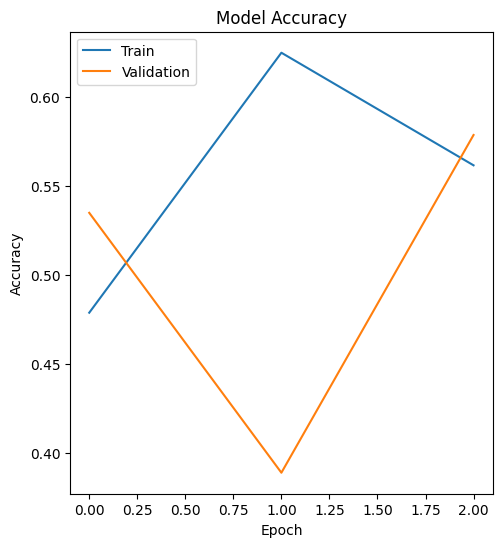

In [35]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

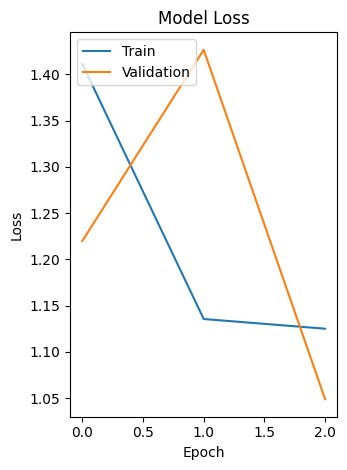

In [36]:

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [37]:
# Calculate model size in megabytes
model_size_mb = os.path.getsize('best_model.h5') / (1024 * 1024)
print(f'Model size: {model_size_mb:.2f} MB')

Model size: 127.44 MB


In [38]:
# Retrieve class indices from the train generator
labels = train_generator.class_indices
print("Class indices from train generator:", labels)

Class indices from train generator: {'asteroid': 0, 'black hole': 1, 'comet': 2, 'constellation': 3, 'nebula': 4}


In [39]:
# Generate predictions using the test data
start_inference_time = time.time()
predictions = model.predict(test_generator)
end_inference_time = time.time()

inference_time = end_inference_time - start_inference_time
print(f'Inference time: {inference_time:.2f} seconds')

13/13 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step
Inference time: 65.67 seconds


In [40]:
y_pred = np.argmax(predictions, axis=1)
print(y_pred)
y_true = test_generator.classes

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

[3 3 3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 3 1 3 3 3 3 1 4 1 3 4 4 4
 3 3 1 4 3 1 1 1 1 1 4 4 4 4 3 4 3 1 3 1 3 3 4 3 3 4 3 1 1 1 3 4 1 4 1 4 4
 4 3 1 3 1 4 4 4 1 3 1 3 4 3 1 4 1 3 4 1 4 3 1 1 1 4 1 3 4 3 3 4 3 3 3 4 4
 4 3 3 3 4 4 3 3 4 4 4 3 3 3 3 4 4 3 3 3 3 3 3 3 3 4 3 3 1 3 3 3 3 3 4 3 4
 3 3 3 3 4 1 3 3 4 3 1 3 3 3 1 3 3 3 4 3 3 3 3 3 3 3 3 3 3 4 1 3 3 3 4 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 3 3 3 3 4 3 3 3 3 3 3 3 3 3 3 1 3 3 3
 3 4 3 3 3 3 3 4 3 3 3 3 3 3 3 3 3 3 4 3 3 4 3 3 4 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 4 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3 4 1 3 3 3 3 3 4 3 3 3 3 3 3 3 4 4 4
 4 4 4 4 4 4 4 4 4 4 3 4 4 4 4 4 4 4 4 4 4 4 4 1 3 4 3 4 4 4 4 4 4 4 4 4 4
 4 1 4 4 4 4 4 4 4 4 4 4 1 3 4 3 4 4 1 4 4 4 4 1 4 1 4 4 4 4 4 4 4 4 4 4 3
 4 4 4 4 4 3 4 4 4 4 3 4 4 4 4 4 3 4 4 4 4 4 4 4 4 3 4 4 4 4 4 4 4 4 4 4 4
 4 4 3 4 4 4]


In [41]:
# Function to plot the confusion matrix with correct labels and class names
def plot_confusion_matrix(cm, classes, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    # Calculate percentages row-wise and annotate the matrix
    for i in range(cm.shape[0]):
        row_sum = np.sum(cm[i, :])
        for j in range(cm.shape[1]):
            percentage = cm[i, j] / row_sum if row_sum > 0 else 0
            text = f'{cm[i, j]}\n({percentage:.2f})'
            plt.text(j, i, text,
                     ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2. else 'black')
    
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

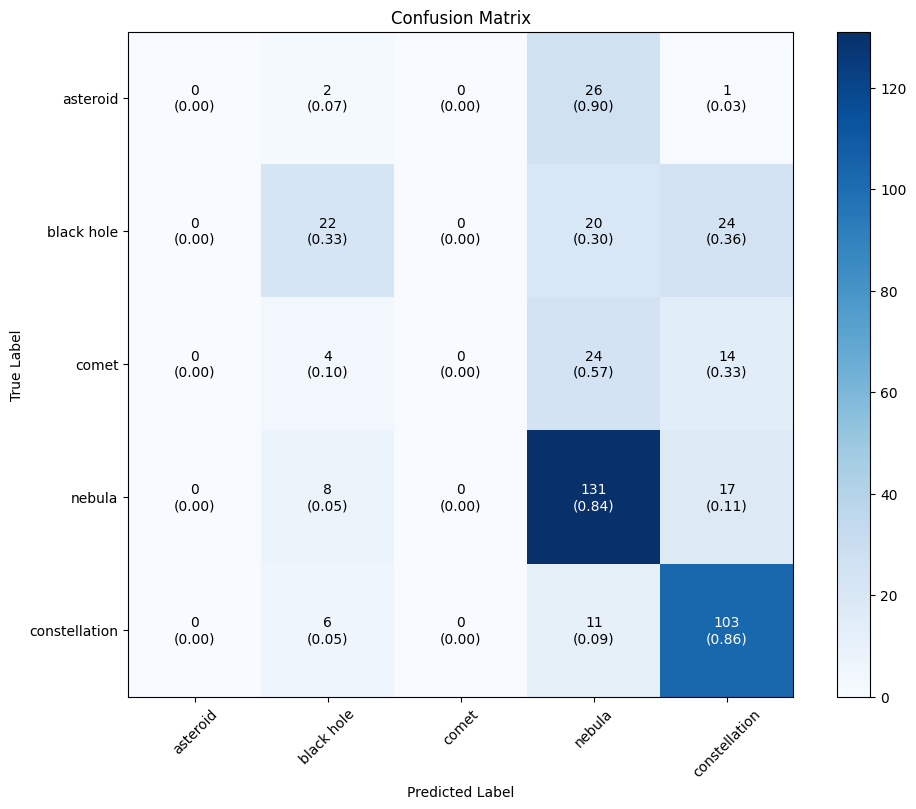

In [42]:
# Plot the confusion matrix with sorted labels and class names
plot_confusion_matrix(cm, selected_classes)

In [45]:
# Calculate and print per-class metrics
for i, class_name in enumerate(selected_classes):
    class_precision = precision_score(y_true, y_pred, labels=[i], average='weighted')
    class_recall = recall_score(y_true, y_pred, labels=[i], average='weighted')
    class_f1 = f1_score(y_true, y_pred, labels=[i], average='weighted')
    class_accuracy = cm[i, i] / np.sum(cm[i, :]) if np.sum(cm[i, :]) > 0 else 0
    
    print(f'\nClass: {class_name}')
    print(f'Accuracy: {class_accuracy:.2f}')
    print(f'Precision: {class_precision:.2f}')
    print(f'Recall: {class_recall:.2f}')
    print(f'F1 Score: {class_f1:.2f}')


Class: asteroid
Accuracy: 0.00
Precision: 0.00
Recall: 0.00
F1 Score: 0.00

Class: black hole
Accuracy: 0.33
Precision: 0.52
Recall: 0.33
F1 Score: 0.41

Class: comet
Accuracy: 0.00
Precision: 0.00
Recall: 0.00
F1 Score: 0.00

Class: nebula
Accuracy: 0.84
Precision: 0.62
Recall: 0.84
F1 Score: 0.71

Class: constellation
Accuracy: 0.86
Precision: 0.65
Recall: 0.86
F1 Score: 0.74


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [54]:
model.save("space-obj-detection.keras")

OSError: [Errno 28] No space left on device

In [ ]:
# Ensure the image exists
if os.path.exists(my_image):
    img = Image.open(my_image)
else:
    raise FileNotFoundError(f"Image not found at {my_image}")
    
# Create the interface
iface = gr.Interface(
    fn=predict_cosmic_object, 
    inputs=[
        gr.components.Image(my_image, label="Cosmic object")  # Use Image input
    ], 
    outputs=gr.components.Textbox(label="Prediction"),
    title="Cosmic object detector",
    description="""Enter your test image of a cosmic object/or alien invader =).""",
)

# Launch the interface
iface.launch(share=True,debug=True)

In [49]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_cosmic_object(test_img):
    print(f"Start predicting {test_img}")
     # Load the image file
#     img_path = '/kaggle/working/dataset/test/constellation/constellation_page_7_image_9_0_SwinIR_large.png'
    img_path = test_img
    # Load and display the original image
    img = image.load_img(img_path)
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    print(img_array.shape)
    plt.imshow(img)
    plt.title('Original Image')
    plt.show()
    img_array = np.expand_dims(img_array, axis=0)
    print(img_array.shape)
    img_array = img_array/255.

    prediction = model.predict(img_array)
    print(f"Prediction array is {prediction}")
    print(f"Done! My prediction is {selected_classes[np.argmax(prediction)]}")
    return prediction

Start predicting /kaggle/working/dataset/test/constellation/constellation_page_10_image_17_aug3_SwinIR_large.png
(224, 224, 3)


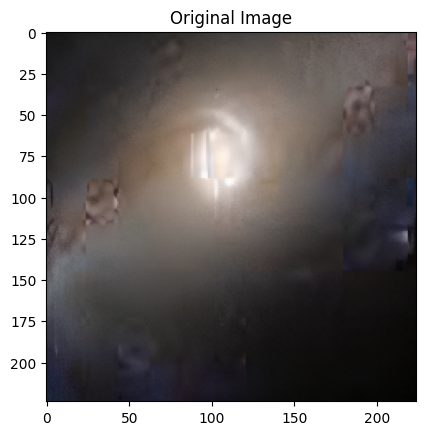

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Prediction array is [[0.14214507 0.23400009 0.1569048  0.21860664 0.24834341]]
Done! My prediction is constellation


array([[0.14214507, 0.23400009, 0.1569048 , 0.21860664, 0.24834341]],
      dtype=float32)

In [52]:
my_image = '/kaggle/working/dataset/test/constellation/constellation_page_10_image_17_aug3_SwinIR_large.png'
predict_cosmic_object(my_image)

Start predicting /kaggle/working/dataset/test/asteroid/asteroid_page_3_image_18_4_SwinIR_large.png
(224, 224, 3)


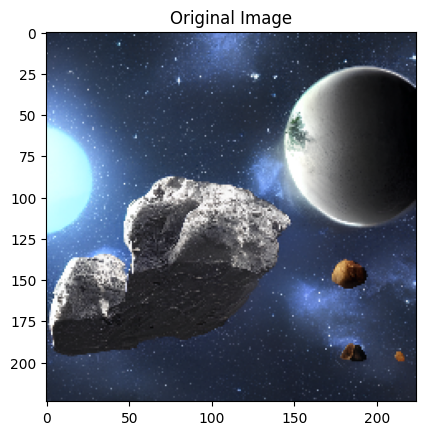

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction array is [[0.22741444 0.02968935 0.20256735 0.4712518  0.06907703]]
Done! My prediction is nebula


array([[0.22741444, 0.02968935, 0.20256735, 0.4712518 , 0.06907703]],
      dtype=float32)

In [53]:
my_image = '/kaggle/working/dataset/test/asteroid/asteroid_page_3_image_18_4_SwinIR_large.png'
predict_cosmic_object(my_image)

In [55]:
!pip install -q gradio

ERROR: Could not find a version that satisfies the requirement gradio (from versions: none)
ERROR: No matching distribution found for gradio


In [ ]:
import gradio as gr
from PIL import Image
# Ensure the image exists
if os.path.exists(my_image):
    img = Image.open(my_image)
else:
    raise FileNotFoundError(f"Image not found at {my_image}")
    
# Create the interface
iface = gr.Interface(
    fn=predict_cosmic_object, 
    inputs=[
        gr.components.Image(my_image, label="Cosmic object")  # Use Image input
    ], 
    outputs=gr.components.Textbox(label="Prediction"),
    title="Cosmic object detector",
    description="""Enter your test image of a cosmic object/or alien invader =).""",
)

# Launch the interface
iface.launch(share=True,debug=True)